In [1]:
format short g

In [2]:
pkg install "https://github.com/gnu-octave/statistics-resampling/archive/refs/heads/master.zip"

The statistics-resampling package was installed into the directory:
/home/jovyan/.local/share/octave/api-v58/packages/statistics-resampling-5.6.1-dev
License and copyright information can be found at:
https://github.com/gnu-octave/statistics-resampling/blob/master/COPYING


In [3]:
pkg load statistics-resampling

In [4]:
[~, genotype] = xlsread ('../data/abeta-cleaned-ver2.xlsx', 'abeta', 'E2:E165');
[~, condition] = xlsread ('../data/abeta-cleaned-ver2.xlsx', 'abeta', 'F2:F165');

% for cell clusters am I averaging from the same cell into one data point
% need to load animal information once it is available

outcomes = xlsread ('../data/abeta-cleaned-ver2.xlsx', 'abeta', 'G2:S165');

disp (size(genotype))
disp (size(condition))
disp (size(outcomes))

          164            1
          164            1
          164           13


In [6]:
% getting rid of columns now as matrix automatically removes NaN, remember that now means that the outcome numbers have shifted 

In [7]:
if (size(outcomes, 2) > 11)
    outcomes(:,[8,13]) = [];
end

disp (size(outcomes))

          164           11


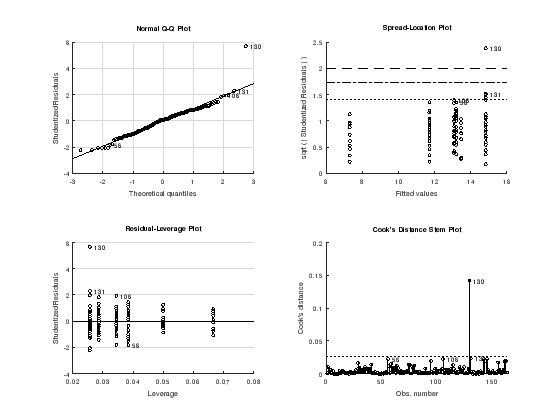

In [8]:
for i = 1: size(outcomes, 2)
    MAT_T = bootlm (outcomes(:,i), {genotype, condition}, 'model', 'full', 'display', 'on', ...
            'contrasts', 'treatment', 'nboot', 0);
    print(sprintf('../output/NC_ver2/outcome%d.png', i), '-dpng', '-r300')
end


In [9]:
% after looking at graphs, outlier rows are: row 2 (outcome 7)  row 130 (outcome 11) (double check)

In [10]:
if (size (outcomes, 1) > 162)
    genotype([2,130],:) = [];
    condition([2,130],:) = [];
    outcomes([2,130],:) = [];
    MAT_T.X([2,130],:) = [];
end

disp (size(genotype))
disp (size(condition))
disp (size(outcomes))
disp (size(MAT_T.X))

          162            1
          162            1
          162           11
          162            6


In [11]:
% bayesian bootstrap summary statistics using Simple Random Sampling

In [12]:
STATS_SRS = bootbayes(outcomes, MAT_T.X);

In [13]:
% can't do cluster bootstrap sampling as of yet, assume Deff = 1

In [14]:
Deff = 1

Deff =     1


In [15]:
% orthogonal (helmert) contrast coding

In [16]:
MAT_H = bootlm (outcomes(:,11), {genotype,condition}, 'model', 'full', ...
                'display', 'off', 'contrasts', 'helmert', 'nboot', 0, 'dim', [1,2]);
MAT_H.C

MAT_H = bootlm (outcomes(:,11), {genotype, condition}, 'model', 'full', ...
                'display', 'off', 'contrasts', MAT_H.C, 'nboot', 0, 'dim', [1,2]);
                
size (MAT_H.X)

ans =
{
  [1,1] =

           -0.5
            0.5

  [1,2] =

       -0.66667            0
        0.33333         -0.5
        0.33333          0.5

}

ans =

          162            6



In [17]:
% fitting model using ridge regression


 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 11

 Sample size: 162

 Design effect (Deff): 1

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 9.12219

 Predicted R-squared: 0.171 (17.1%)

 Bootstrap optimized ridge tuning constant (lambda): 3.90398

 Effective residual degrees of freedom (df_lambda): 157.

 Residual variances (range): [0.138, 4.39e+03]

 Inferential degrees of freedom (df_t): 157.
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             -0.02540      -0.1820       +0.1324  
 1             3             +0.7310       +0.6483       +0.7967  
 1             4             +0.1763       +0.

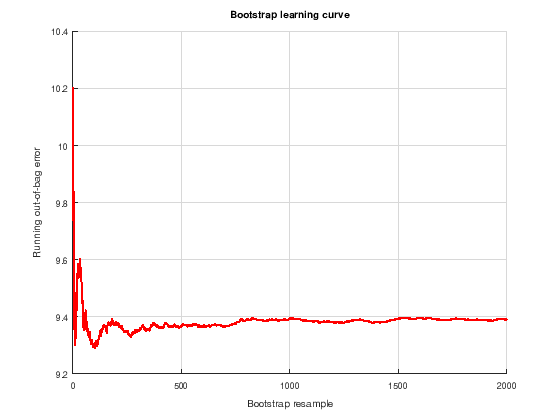

In [18]:
tic
bootridge(outcomes, MAT_H.X, '*', 1999, 0.05, [], Deff);
toc
ridge_coeff = ans;

In [19]:
% stability selection, rate has to be 97.5

In [20]:
disp (ridge_coeff.stability*100)

 Columns 1 through 6:

          NaN          NaN          NaN          NaN          NaN          NaN
       99.825       87.275       99.875       86.425       99.825       99.975
       99.975       99.975       95.175       99.925       99.975       99.975
       99.975       62.775       99.975       91.175       95.275       99.475
       99.975       67.775       99.775       62.925       54.275       83.125
       83.175       83.875       99.625       99.975       98.925       81.975

 Columns 7 through 11:

          NaN          NaN          NaN          NaN          NaN
       99.975       99.225       99.925       99.475       95.025
       99.975       99.975       68.125       96.425       99.975
       91.725       60.875       92.125       92.375       71.225
       95.675       70.075       84.325       81.175       99.925
       83.025       70.225       90.025       99.975       60.175


In [22]:
ridge_coeff.BF10

ans =

 Columns 1 through 6:

          NaN          NaN          NaN          NaN          NaN          NaN
       8.3496      0.56825       16.374      0.47122       5.6026       384.85
       409.63   1.0168e+11      0.68041       25.259        318.3        27707
       754.57      0.38841       1708.5      0.72207       1.2652       3.3572
       8.3914      0.61921       2.9747      0.58194      0.56759      0.72666
      0.86519       0.8622       8.2283       8.5655       2.7546      0.75977

 Columns 7 through 11:

          NaN          NaN          NaN          NaN          NaN
   6.7067e+05       4.1439       49.769       3.7591       0.8477
   4.0163e+06       240.73      0.34603        2.053       181.67
      0.68296      0.37783      0.98845      0.65028      0.42099
       1.3331      0.63858      0.70288      0.76692       4.4191
      0.77307      0.67233       1.0517       5.0557      0.63804



In [24]:
%{
reminder- 
1. intercept, represnts grand mean
2. G2 - G1 averaged over conditions
3. C5C6 - C4 averaged over genotypes
4. C6 - C5 averaged over genotypes
5. is [G2 -G1] different in C5C6 compared to C4
6. is [G2 -G1] different in C6 compared to C5 
%}

In [25]:
%{
outcome numbers now corresponds to (after removing 8 and 13) : 
1. peak
2. afterhyp
3. amp 
4. thresh
5. half (full-width at half maximum)
6. rise 
7. fall 
8. rheobase (current it takes to reach thresh)
9. sag (IH sag)
10. RMP (resting membrane potential)
11. maxApnum
%}

In [26]:
%{
20.87 % of posterior precision is due to prior precision
%}

In [27]:
%{
: coeff (), lnBF10 () BF10 () SS ()
%}

In [ ]:
%{
1. peak
2: coeff ( -3.732), lnBF10 (+2.12) BF10 (8.3496) SS (99.825)
3: coeff (-5.823 ), lnBF10 (+6.02) BF10 (409.63) SS (99.975)
4: coeff (-6.861), lnBF10 (+6.63) BF10 (754.57) SS (99.975)
5: coeff (-6.179), lnBF10 (+2.13) BF10 (8.3914) SS (99.975)

2. afterhyp
3: coeff (+5.531), lnBF10 (+25.3) BF10 (1.0168e+11) SS (99.975)

3. amp
2: coeff (-4.810), lnBF10 (+2.80) BF10 (16.374) SS (99.875)
4: coeff (-8.483), lnBF10 (+7.44) BF10 (1708.5) SS (99.975)
5: coeff (-5.663), lnBF10 (+1.09) BF10 (2.9747) SS (99.775)
6: coeff (-7.816), lnBF10 (+2.11) BF10 (8.2283) SS (99.625)

4. thresh
3: coeff (-3.662), lnBF10 (+3.23) BF10 (25.259) SS (99.925)
6: coeff (+5.461), lnBF10 (+2.15) BF10 (8.5655) SS (99.975)

5. half
2: coeff (+0.1404), lnBF10 (+1.72) BF10 (5.6026) SS (99.825)
3: coeff (+0.2296), lnBF10 (+5.76) BF10 (318.3) SS (99.975)
6: coeff (-0.2026), lnBF10 (+1.01) BF10 (2.7546) SS (98.925)

6. rise
2: coeff (-28.26), lnBF10 (+5.95) BF10 (384.85) SS (99.975)
3: coeff (-37.87), lnBF10 (+10.2) BF10 (27707) SS (99.975)
4: coeff (-18.48), lnBF10 (+1.21) BF10 (3.3572) SS (99.475)

7. fall
2: coeff (+6.900), lnBF10 (+13.4) BF10 (6.7067e+05) SS (99.975)
3: coeff (+7.689), lnBF10 (+15.2) BF10 (4.0163e+06) SS (99.975)

8. rheobase
2: coeff (-23.68), lnBF10 (+1.42) BF10 (4.1439) SS (99.225)
3: coeff (-40.07), lnBF10 (+5.48) BF10 (240.73) SS (99.975)

9. sag
2: coeff (+2.752), lnBF10 (+3.91) BF10 (49.769) SS (99.925)

10. RMP
2: coeff (+1.994), lnBF10 (+1.32) BF10 (3.7591) SS (99.475)
6: coeff (+3.690), lnBF10 (+1.62) BF10 (5.0557) SS (99.975)

11. maxapnum 
3: coeff (+3.299), lnBF10 (+5.20) BF10 (181.67) SS (99.975)
5: coeff (+3.248), lnBF10 (+1.49) BF10 (4.4191) SS (99.925)

%}

In [ ]:
%{
11: maxApnum
3. C5C6 - C4 averaged over genotypes
3: coeff ( +3.299 ), lnBF10 (+5.2) BF10 (181.67) SS (99.975)

strong evidence for a 3 Hz increase in firing frequency when comparing both abeta conditions over controls

5. is [G2 -G1] different in C5C6 compared to C4
5: coeff (+3.248), lnBF10 (+1.49) BF10 (4.4191) SS (99.925)

good evidence for a 3 Hz increase in firing frequency between genotypes

%}

In [28]:
% correlation for pairs of outcomes involving column 11 (max Apnum)

In [29]:
RTAB = ridge_coeff.RTAB;
disp(min(RTAB(:,3)));
disp(max(RTAB(:,3)));
contains_maxApnum = any (RTAB(:,1:2) == 11, 2);
RTAB(contains_maxApnum,:)

-0.6215
0.85746
ans =

            1           11      0.16348    0.0063312      0.31275
            2           11      0.33879       0.1917        0.471
            3           11      0.51887      0.39369      0.62515
            4           11     -0.54729     -0.64874     -0.42671
            5           11     -0.10174     -0.25497     0.056475
            6           11      0.56453      0.44691      0.66297
            7           11     -0.31164     -0.44703     -0.16228
            8           11     -0.56542      -0.6637     -0.44795
            9           11    0.0083623     -0.14915      0.16546
           10           11      -0.1821     -0.32996    -0.025518




 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 11

 Sample size: 162

 Design effect (Deff): 1

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 9.12219

 Predicted R-squared: 0.171 (17.1%)

 Bootstrap optimized ridge tuning constant (lambda): 3.90398

 Effective residual degrees of freedom (df_lambda): 157.

 Residual variances (range): [0.138, 4.39e+03]

 Inferential degrees of freedom (df_t): 157.
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             -0.02540      -0.1820       +0.1324  
 1             3             +0.7310       +0.6483       +0.7967  
 1             4             +0.1763       +0.

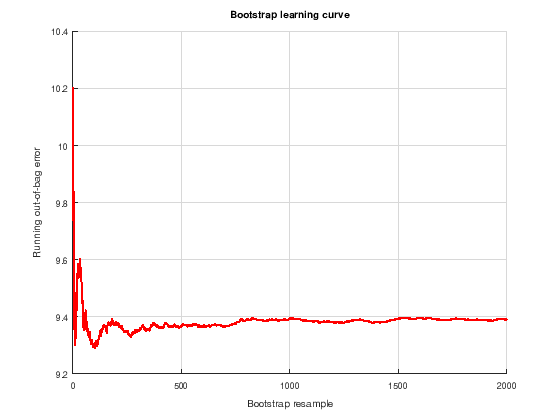

In [30]:
tic 
bootridge (outcomes, MAT_H.X, '*', 1999, 0.05, MAT_H.L, Deff);
toc
ridge_emm = ans;

In [31]:
ridge_emm

ridge_emm =

  scalar structure containing the fields:

    function = bootridge
    estimate =

     Columns 1 through 5:

           48.517      -12.302       89.156      -40.639       1.6164
           48.904      -11.911       88.122      -39.218       1.7631
           48.625      -7.1709       92.115       -43.49       1.8545
           44.011      -5.7164       89.326      -45.314       2.0931
           42.942      -6.8927        87.54      -44.598        1.847
           35.973      -6.5233       76.934      -40.962        1.883

     Columns 6 through 10:

           200.59      -45.756        146.8       6.6371      -64.826
           178.68      -40.814       129.34       8.7032      -61.986
            174.4       -40.75       114.85       6.7295      -65.626
           147.61      -32.063       84.046       10.704        -65.9
           160.56      -38.321       107.94       6.1805      -66.342
           124.48       -31.25       85.169       8.3954      -62.926

     C

In [32]:
comparisons = [2 1; 4 3; 6 5]

comparisons =

            2            1
            4            3
            6            5



In [33]:
MAT_H_PAIRS = bootlm (outcomes(:,11), {genotype, condition}, 'model', 'full', ...
                     'display', 'off', 'contrasts', MAT_H.C, 'nboot', 0, 'dim', [1,2], 'posthoc', comparisons);


 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 11

 Sample size: 162

 Design effect (Deff): 1

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 9.12219

 Predicted R-squared: 0.171 (17.1%)

 Bootstrap optimized ridge tuning constant (lambda): 3.90398

 Effective residual degrees of freedom (df_lambda): 157.

 Residual variances (range): [0.138, 4.39e+03]

 Inferential degrees of freedom (df_t): 157.
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             -0.02540      -0.1820       +0.1324  
 1             3             +0.7310       +0.6483       +0.7967  
 1             4             +0.1763       +0.

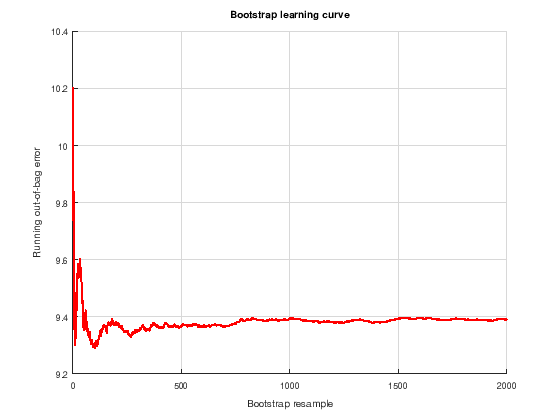

In [34]:
tic
bootridge (outcomes, MAT_H_PAIRS.X, '*', 1999, 0.05, ...
          MAT_H_PAIRS.L, Deff);
toc
ridge_pairs = ans;


In [35]:
ridge_pairs

ridge_pairs =

  scalar structure containing the fields:

    function = bootridge
    estimate =

     Columns 1 through 5:

          0.38738      0.39051      -1.0344       1.4218      0.14674
          -4.6135       1.4545      -2.7891      -1.8245      0.23859
          -6.9688      0.36937      -10.605       3.6365     0.035957

     Columns 6 through 10:

          -21.914       4.9422      -17.455       2.0661       2.8397
          -26.785       8.6864      -30.803       3.9749     -0.27365
          -36.078       7.0711       -22.77       2.2149        3.416

     Column 11:

          -3.4032
         -0.33821
         0.027853

    CI_lower =

     Columns 1 through 5:

          -4.0827      -1.6801      -6.2735        -2.21    -0.032904
          -8.8646     -0.51462      -7.7714      -5.2783      0.06775
          -11.567      -1.7608      -15.995    -0.099749     -0.14886

     Columns 6 through 10:

          -44.661       1.1526      -49.482     -0.57439     0.089418
